# 10v5_05 — test_simulated 1k pilot (1k ONLY; 3k/10k stay gated behind this notebook's SCALE_GO)

**Question.** Does `test_simulated` restore meaningful spectral discrimination on test-like
queries while avoiding obvious T1 duplicate leakage? This is **not** "which protocol scores
highest".

* **Protocols.** These are fixed before any metric by `10v5_04`
  (`outputs/v5/protocols/test_simulated_definition.json`):
  * `mirror_aware` (benchmark);
  * `test_simulated_strict`;
  * `test_simulated_relaxed`, only if the pre-registered T2 rule requires it;
  * `standard`, labeled **STANDARD — OPTIMISTIC / DUPLICATE-PERMITTING SENSITIVITY**, which is
    never selectable.
* **Training.** The base is TL_1K. For each protocol, the query subset is those whose truth is in
  the pool with at least one eligible reference **under that protocol**. TL_1K itself is never
  modified.
* **Model.** The exact V1 recipe. No new feature and no tuning.
* **Evaluation.** The same fixed TL_EVAL for every model, with evidence built under the model's
  own protocol. Populations: ALL, the protocol's own Mode-A subset, STANDARD_ONLY, historical
  MODE_A_MIRROR, and REF_ABSENT. B1 (mass only) and frozen B5 (no retuning) are included.
* **SCALE_GO** (`casmi.ranking.protocol_decision.SCALE_GO_RULE`, pre-registered). Semantic
  validity is checked first, then evidence size, then V1 > B1. Stricter is preferred, and relaxed
  is never selected automatically. The decision is written **before** HOST is scored. HOST is
  confirmation only.

Features come from the existing QCR by filter and aggregation only. No similarity is recomputed.

In [1]:
import sys, json, hashlib
from pathlib import Path

REPO_ROOT = Path.cwd()
if not (REPO_ROOT / 'src').exists() and (REPO_ROOT.parent / 'src').exists():
    REPO_ROOT = REPO_ROOT.parent
if str(REPO_ROOT / 'src') not in sys.path:
    sys.path.insert(0, str(REPO_ROOT / 'src'))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from casmi.paths import get_project_paths
from casmi.qcr.context import SEED, config_hash, v4b_paths, v5_paths
from casmi.qcr.fingerprint import code_version
from casmi.qcr.protocols import (PROTOCOL_DEFS, aggregate_protocol, assert_walk_complete, coverage_row, derive_protocol_manifest,
                                 features_from_shards, forbidden_tier_counts, protocol_counts_from_shards, protocol_semantics_table,
                                 select_protocol_refs, truth_evidence_ids)
from casmi.qcr.settlement import load_settlement_or_refuse
from casmi.ranking.baselines import b1, fusion
from casmi.ranking.lambdamart import BASE_FEATURES, LGBM_PARAMS, fit_fold_models, save_fold_models
from casmi.ranking.manifests import load_manifest, save_manifest
from casmi.ranking.mass_likelihood import MassLikelihoodModel
from casmi.ranking.protocol_decision import SCALE_GO_RULE, scale_go_decision
from casmi.ranking.rank_eval import summarize
from casmi.ranking.scaling import score_population
from casmi.ranking.selection import write_preregistration
from casmi.validation.cluster_bootstrap import cluster_bootstrap_mean, paired_comparison_row
from casmi.validation.decision_log import log_decision
from casmi.validation.regime_audit import MODE_A_MIRROR, REF_ABSENT, STANDARD_ONLY, load_regimes

pd.set_option('display.max_columns', 60); pd.set_option('display.width', 220)
paths = get_project_paths()
vp, D = v4b_paths(paths), v5_paths(paths)
PILOT, PROTO = D['root'] / 'pilot', D['root'] / 'protocols'
(PILOT / 'models').mkdir(parents=True, exist_ok=True)
(D['features'] / 'protocols').mkdir(parents=True, exist_ok=True)
N_BOOT, KEY = 2000, 'candidate_connectivity_key'
settlement = load_settlement_or_refuse(vp.settlement_json)
ARTS = settlement['evidence_artifacts']
DEF = json.loads((PROTO / 'test_simulated_definition.json').read_text(encoding='utf-8'))
T2 = DEF['t2_decision']
TESTSIM = list(T2['protocols'])                                   # strict, or strict + relaxed -- fixed by provenance, not by score
PROTOCOLS = ['mirror_aware', *TESTSIM, 'standard']
MODEL_ID = {'mirror_aware': 'V1_MIRROR_1K', 'test_simulated_strict': 'V1_TESTSIM_STRICT_1K', 'test_simulated_relaxed': 'V1_TESTSIM_RELAXED_1K',
            'standard': 'V1_STANDARD_SENS_1K'}
SUFFIX = {'mirror_aware': 'MIRROR', 'test_simulated_strict': 'TESTSIM_STRICT', 'test_simulated_relaxed': 'TESTSIM_RELAXED', 'standard': 'STANDARD_SENS'}
prereg = write_preregistration(PILOT / 'preregistration_pilot.json', rule={
    'rule_id': 'v5.2-pilot-1', 'protocols': PROTOCOLS, 't2_decision': {k: T2[k] for k in ('t2_policy', 'q_t34', 'q_t12_only', 'protocols')},
    'scale_go': SCALE_GO_RULE, 'recipe': 'exact V1 (BASE_FEATURES, LGBM_PARAMS, lambdarank, 5 connectivity folds, seed 42)',
    'evaluation': 'fixed TL_EVAL; populations ALL / protocol Mode-A / STANDARD_ONLY / MODE_A_MIRROR / REF_ABSENT; B1 + frozen B5',
    'host_role': 'confirmation only, scored after scale_go_decision.json is written',
    'standard_role': 'STANDARD -- OPTIMISTIC / DUPLICATE-PERMITTING SENSITIVITY; never selectable'})
print('protocols:', PROTOCOLS, '| T2 policy:', T2['t2_policy'], '| pilot rule sha256:', prereg['rule_sha256'])

protocols: ['mirror_aware', 'test_simulated_strict', 'standard'] | T2 policy: STRICT_ONLY | pilot rule sha256: da060d1ddcb2c2f3d7bee67fa5c2fe377e20a2026915e7395e36a00f37839a40


## 1. Protocol features + counts from EXISTING QCR (TL_1K, TL_EVAL, HOST)

In [2]:
def shards(unit, kind='qcr'):
    return sorted((D['qcr'] / unit / kind / 'shards').glob('part-*.parquet'))


TL1K_MAN, TL1K_META = load_manifest('TL_1K', D['manifests'])
TL_MAN, _ = load_manifest('TL_EVAL', D['manifests'])
TL_REG = load_regimes('TL_EVAL', D['root'] / 'regimes')
host_q = pd.read_parquet(vp.host_processed / 'host_holdout_spectra.parquet')
POOLS = {'TL_1K': pd.read_parquet(D['features'] / 'units' / 'TL_1K_pool.parquet'), 'TL_EVAL': pd.read_parquet(D['features'] / 'units' / 'TL_EVAL_pool.parquet'),
         'HOST': pd.read_parquet(ARTS['host_features_mirror_aware'], columns=['query_id', KEY, 'abs_mass_error_ppm', 'is_true_candidate'])}
META = {'TL_1K': TL1K_MAN, 'TL_EVAL': TL_MAN,
        'HOST': host_q.rename(columns={'true_connectivity_key': 'connectivity_key', 'ingest_lib': 'source', 'instrument_type': 'instrument'})}
FEATS, COUNTS, AUDIT = {}, {}, {}
for ds in ('TL_1K', 'TL_EVAL'):
    COUNTS[ds] = protocol_counts_from_shards(shards(ds), shards(ds, 'qcr_pairs'), POOLS[ds], PROTOCOLS)
host_qcr = pd.read_parquet(ARTS['host_qcr'])
COUNTS['HOST'] = protocol_counts_from_shards([ARTS['host_qcr']], [ARTS['host_qcr_pairs']], POOLS['HOST'], PROTOCOLS)
mcols = ['query_id', 'connectivity_key', 'fold', 'source', 'instrument', 'adduct']
for ds in ('TL_1K', 'TL_EVAL', 'HOST'):
    m = META[ds][mcols].rename(columns={'connectivity_key': 'true_connectivity_key'})
    for p in PROTOCOLS:
        if p != 'mirror_aware':
            assert_walk_complete(COUNTS[ds][p])
        if ds == 'HOST':
            f = aggregate_protocol(host_qcr, POOLS['HOST'], PROTOCOL_DEFS[p])
            audit = select_protocol_refs(host_qcr, PROTOCOL_DEFS[p])[['query_id', 'candidate_key', 'is_true', 'tier', 'ref_source', 'query_source']]
        else:
            f, audit = features_from_shards(shards(ds), POOLS[ds], PROTOCOL_DEFS[p])
        FEATS[(ds, p)] = f.merge(m, on='query_id', how='left')
        AUDIT[(ds, p)] = forbidden_tier_counts(audit, PROTOCOL_DEFS[p])
        if p != 'mirror_aware':
            FEATS[(ds, p)].to_parquet(D['features'] / 'protocols' / f'{ds}_{p}.parquet', index=False)
            COUNTS[ds][p].to_parquet(PROTO / f'{ds}_{p}_counts.parquet', index=False)
del host_qcr
# consistency: the filter-built mirror_aware TL_EVAL features equal the persisted v5 features
persisted = pd.read_parquet(D['features'] / 'TL_EVAL_mirror_aware.parquet').sort_values(['query_id', KEY]).reset_index(drop=True)
rebuilt = FEATS[('TL_EVAL', 'mirror_aware')].sort_values(['query_id', KEY]).reset_index(drop=True)
def _maxdiff(a, b):
    a, b = np.asarray(a, float), np.asarray(b, float)
    d = np.where(np.isnan(a) & np.isnan(b), 0.0, np.abs(a - b))
    return float(np.max(np.where(np.isnan(d), np.inf, d))) if len(d) else 0.0


mx = max(_maxdiff(persisted[c], rebuilt[c]) for c in BASE_FEATURES)
assert len(persisted) == len(rebuilt) and mx <= 1e-12, f'filter-built mirror_aware features differ from the persisted ones (max {mx})'
display(pd.DataFrame(AUDIT).T)

c:\Users\myben\OneDrive\Documents\Enveda\src\casmi\qcr\protocols.py:293: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  c["exhausted"] = c["exhausted"].fillna(True).astype(bool)
c:\Users\myben\OneDrive\Documents\Enveda\src\casmi\qcr\protocols.py:293: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  c["exhausted"] = c["exhausted"].fillna(True).astype(bool)
c:\Users\myben\OneDrive\Documents\Enveda\src\casmi\qcr\protocols.py:293: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call res

t1_violation_count  forbidden_tier_count  same_source_violation_count
TL_1K   mirror_aware                            0                     0                            0
        test_simulated_strict                   0                     0                            0
        standard                                0                     0                            0
TL_EVAL mirror_aware                            0                     0                            0
        test_simulated_strict                   0                     0                            0
        standard                                0                     0                            0
HOST    mirror_aware                            0                     0                            0
        test_simulated_strict                   0                     0                            0
        standard                                0                     0                            0

## 2. Protocol-matched Mode-A training subsets of TL_1K (TL_1K itself never modified)

In [3]:
TRAIN_MAN, TRAIN_AUDIT = {}, {}
host_keys, tl_keys = set(host_q['true_connectivity_key']), set(TL_MAN['connectivity_key'])
for p in PROTOCOLS:
    name = f'TL_1K_{SUFFIX[p]}'
    dm, aud = derive_protocol_manifest(TL1K_MAN, COUNTS['TL_1K'][p], SUFFIX[p])
    assert set(dm['query_id']) <= set(TL1K_MAN['query_id'])
    assert set(dm['query_id']) <= truth_evidence_ids(COUNTS['TL_1K'][p])
    assert not (set(dm['connectivity_key']) & host_keys) and not (set(dm['connectivity_key']) & tl_keys)
    if p in TESTSIM:
        save_manifest(dm, name, D['manifests'], extra={'derived_from': 'TL_1K', 'protocol': p, **aud})
    TRAIN_MAN[p], TRAIN_AUDIT[p] = dm, aud
assert load_manifest('TL_1K', D['manifests'])[1]['manifest_sha256'] == TL1K_META['manifest_sha256'], 'TL_1K was modified'
display(pd.DataFrame(TRAIN_AUDIT).T)

,n_original,n_retained,retention_rate
mirror_aware,1000.0,18.0,0.018
test_simulated_strict,1000.0,1000.0,1.000
standard,1000.0,1000.0,1.000


## 3. Train the pilot models (exact V1 recipe; one per protocol)

In [4]:
MODELS, N_TRAIN = {}, {}
for p in PROTOCOLS:
    tr = FEATS[('TL_1K', p)]
    tr = tr[tr['query_id'].isin(set(TRAIN_MAN[p]['query_id']))]
    assert tr[tr['is_true_candidate']].groupby('query_id')['n_reference_spectra'].min().ge(1).all()
    folds = sorted(tr['fold'].unique())
    assert len(folds) == 5
    models, _ = fit_fold_models(tr, BASE_FEATURES, fold_col='fold', folds=folds, params=LGBM_PARAMS)
    save_fold_models(models, PILOT / 'models' / MODEL_ID[p], BASE_FEATURES, LGBM_PARAMS, tr['query_id'].unique(),
                     extra={'model_id': MODEL_ID[p], 'protocol': p, 'protocol_label': PROTOCOL_DEFS[p].label, 'seed': SEED, 'code_version': code_version()})
    MODELS[p], N_TRAIN[p] = models, int(tr['query_id'].nunique())
print(N_TRAIN)

{'mirror_aware': 18, 'test_simulated_strict': 1000, 'standard': 1000}


## 4. Common TL_EVAL evaluation (same fixed queries; evidence under each model's own protocol)

In [5]:
TL_IDS = TL_MAN['query_id'].tolist()
CLUSTER = TL_MAN.set_index('query_id')['connectivity_key'].to_dict()
REGIME_POPS = {'ALL': TL_IDS, 'STANDARD_ONLY': TL_REG.loc[TL_REG['regime'] == STANDARD_ONLY, 'query_id'].tolist(),
               'MODE_A_MIRROR (historical)': TL_REG.loc[TL_REG['regime'] == MODE_A_MIRROR, 'query_id'].tolist(),
               'REF_ABSENT': TL_REG.loc[TL_REG['regime'] == REF_ABSENT, 'query_id'].tolist()}
for p in PROTOCOLS:
    ev = truth_evidence_ids(COUNTS['TL_EVAL'][p])
    REGIME_POPS[f'MODE_A under {p}'] = [q for q in TL_IDS if q in ev]
v4b_lock = json.loads((vp.out / 'dev_selection_lock.json').read_text(encoding='utf-8'))
B5_ALPHA, B5_STD = float(v4b_lock['alphas']['B5']), v4b_lock['dev_standardizer']
mass_model = MassLikelihoodModel.from_dict(json.loads((vp.out / 'metrics' / 'mass_likelihood_model.json').read_text(encoding='utf-8')))


def with_mass_loglik(df):
    d = df.rename(columns={'instrument': 'instrument_type'})
    return d.assign(mass_loglik=mass_model.loglik(d)[0])


PQ = {}
for p in PROTOCOLS:
    PQ[MODEL_ID[p]] = score_population(MODELS[p], FEATS[('TL_EVAL', p)], BASE_FEATURES, TL_IDS)[0]
    PQ[f'B5_frozen_v4b [{p}]'] = fusion(with_mass_loglik(FEATS[('TL_EVAL', p)]), TL_IDS, 'modified_cosine_max', B5_ALPHA, B5_STD)
PQ['B1_mass'] = b1(FEATS[('TL_EVAL', 'mirror_aware')], TL_IDS)
rows = []
for m, pq in PQ.items():
    for pop, ids in REGIME_POPS.items():
        rows.append({'model': m, 'population': pop, **summarize(pq[pq['query_id'].isin(set(ids))])})
metrics = pd.DataFrame(rows)
metrics.to_csv(PILOT / 'pilot_metrics.csv', index=False)
display(metrics.pivot_table(index='model', columns='population', values='mrr_at_25').round(4))
display(metrics.pivot_table(index='model', columns='population', values='n_queries'))

population,ALL,MODE_A under mirror_aware,MODE_A under standard,MODE_A under test_simulated_strict,MODE_A_MIRROR (historical),REF_ABSENT,STANDARD_ONLY
model,,,,,,,
B1_mass,0.1418,0.2129,0.1418,0.1418,0.2129,0.1250,0.1408
B5_frozen_v4b [mirror_aware],0.1274,0.9286,0.1275,0.1275,0.9286,0.1000,0.1161
B5_frozen_v4b [standard],0.8023,0.8609,0.8039,0.8039,0.8609,0.0000,0.8031
B5_frozen_v4b [test_simulated_strict],0.8023,0.8609,0.8039,0.8039,0.8609,0.0000,0.8031
V1_MIRROR_1K,0.0625,1.0000,0.0627,0.0627,1.0000,0.0000,0.0493
V1_STANDARD_SENS_1K,0.9661,0.9365,0.9675,0.9675,0.9365,0.2500,0.9680
V1_TESTSIM_STRICT_1K,0.9671,0.9365,0.9687,0.9687,0.9365,0.2083,0.9691


population,ALL,MODE_A under mirror_aware,MODE_A under standard,MODE_A under test_simulated_strict,MODE_A_MIRROR (historical),REF_ABSENT,STANDARD_ONLY
model,,,,,,,
B1_mass,1000.0,14.0,998.0,998.0,14.0,2.0,984.0
B5_frozen_v4b [mirror_aware],1000.0,14.0,998.0,998.0,14.0,2.0,984.0
B5_frozen_v4b [standard],1000.0,14.0,998.0,998.0,14.0,2.0,984.0
B5_frozen_v4b [test_simulated_strict],1000.0,14.0,998.0,998.0,14.0,2.0,984.0
V1_MIRROR_1K,1000.0,14.0,998.0,998.0,14.0,2.0,984.0
V1_STANDARD_SENS_1K,1000.0,14.0,998.0,998.0,14.0,2.0,984.0
V1_TESTSIM_STRICT_1K,1000.0,14.0,998.0,998.0,14.0,2.0,984.0


## 5. Connectivity-cluster bootstrap and paired deltas (same TL_EVAL queries)

In [6]:
pairs = [(MODEL_ID['test_simulated_strict'], MODEL_ID['mirror_aware'])]
if 'test_simulated_relaxed' in TESTSIM:
    pairs += [(MODEL_ID['test_simulated_relaxed'], MODEL_ID['mirror_aware']), (MODEL_ID['test_simulated_relaxed'], MODEL_ID['test_simulated_strict'])]
pairs += [(MODEL_ID[p], 'B1_mass') for p in PROTOCOLS]
boot = []
for pop in ('ALL', 'STANDARD_ONLY'):
    ids = set(REGIME_POPS[pop])
    for a, b in pairs:
        boot.append({'population': pop, **paired_comparison_row(a, PQ[a][PQ[a]['query_id'].isin(ids)], b, PQ[b][PQ[b]['query_id'].isin(ids)],
                                                                CLUSTER, n_boot=N_BOOT, seed=SEED)})
    for m in PQ:
        s = PQ[m][PQ[m]['query_id'].isin(ids)]
        boot.append({'population': pop, 'comparison': f'{m} (CI)', **cluster_bootstrap_mean(s['rr'].to_numpy(), s['query_id'].map(CLUSTER).to_numpy(),
                                                                                              n_boot=N_BOOT, seed=SEED)})
boot = pd.DataFrame(boot)
boot.to_csv(PILOT / 'pilot_bootstrap.csv', index=False)
display(boot[['population', 'comparison', 'delta', 'mean', 'ci_low', 'ci_high', 'excludes_zero']].round(4))

,population,comparison,delta,mean,ci_low,ci_high,excludes_zero
0,ALL,V1_TESTSIM_STRICT_1K vs V1_MIRROR_1K,0.9046,NaN,0.8900,0.9183,True
1,ALL,V1_MIRROR_1K vs B1_mass,-0.0792,NaN,-0.0925,-0.0667,True
2,ALL,V1_TESTSIM_STRICT_1K vs B1_mass,0.8254,NaN,0.8075,0.8428,True
3,ALL,V1_STANDARD_SENS_1K vs B1_mass,0.8243,NaN,0.8062,0.8417,True
4,ALL,V1_MIRROR_1K (CI),NaN,0.0625,0.0524,0.0734,NaN
5,ALL,B5_frozen_v4b [mirror_aware] (CI),NaN,0.1274,0.1139,0.1422,NaN
6,ALL,V1_TESTSIM_STRICT_1K (CI),NaN,0.9671,0.9570,0.9761,NaN
7,ALL,B5_frozen_v4b [test_simulated_strict] (CI),NaN,0.8023,0.7821,0.8207,NaN
8,ALL,V1_STANDARD_SENS_1K (CI),NaN,0.9661,0.9558,0.9751,NaN
9,ALL,B5_frozen_v4b [standard] (CI),NaN,0.8023,0.7824,0.8208,NaN


## 6. Pre-registered SCALE_GO decision (written BEFORE HOST is scored)

In [7]:
b1_all = summarize(PQ['B1_mass'])['mrr_at_25']
cov = {p: coverage_row(COUNTS['TL_EVAL'][p], TL_IDS, p) for p in PROTOCOLS}
evidence = {}
for p in TESTSIM:
    evidence[p] = {'protocol': p, 'semantics_allowed': p in T2['protocols'], 'n_eval_truth_evidence': len(REGIME_POPS[f'MODE_A under {p}']),
                   'tl_eval_truth_coverage': cov[p]['truth_ge1'], 'v1_mrr_all': summarize(PQ[MODEL_ID[p]])['mrr_at_25'], 'b1_mrr_all': b1_all,
                   't1_violation_count': sum(AUDIT[(ds, p)]['t1_violation_count'] for ds in ('TL_1K', 'TL_EVAL')),
                   'forbidden_tier_count': sum(AUDIT[(ds, p)]['forbidden_tier_count'] for ds in ('TL_1K', 'TL_EVAL'))}
GO = scale_go_decision(evidence, T2)
GO['pilot_rule_sha256'] = prereg['rule_sha256']
GO['definition_sha256'] = DEF['definitions'][DEF['primary']]['definition_sha256']
(PILOT / 'scale_go_decision.json').write_text(json.dumps(GO, indent=2, default=str), encoding='utf-8')
log_decision(decision=f"v5.2 SCALE_GO: next_step={GO['next_step']} selected_protocol={GO['selected_protocol']}",
             evidence_used='pilot_metrics.csv, protocol audits; HOST not yet scored', host_visible=False, category='pre_registered_choice',
             log_path=paths.outputs / 'decision_log.jsonl')
print(json.dumps({k: GO[k] for k in ('selected_protocol', 'protocol_status', 'eligible_for_scaling', 'reasons', 'next_step')}, indent=1, default=str))

{
 "selected_protocol": "test_simulated_strict",
 "protocol_status": "ELIGIBLE",
 "eligible_for_scaling": true,
 "reasons": [
  "all pre-registered checks satisfied"
 ],
 "next_step": "RUN_3K_10K_SCALING"
}


## 7. HOST confirmation (descriptive only; the decision above is already persisted)

In [8]:
HOST_IDS = host_q['query_id'].tolist()
HOST_CLUSTER = host_q.set_index('query_id')['true_connectivity_key'].to_dict()
host_rows = []
for p in PROTOCOLS:
    pq = score_population(MODELS[p], FEATS[('HOST', p)], BASE_FEATURES, HOST_IDS)[0]
    ci = cluster_bootstrap_mean(pq['rr'].to_numpy(), pq['query_id'].map(HOST_CLUSTER).to_numpy(), n_boot=N_BOOT, seed=SEED)
    host_rows.append({'model': MODEL_ID[p], 'protocol': p, **summarize(pq), 'ci_low': ci['ci_low'], 'ci_high': ci['ci_high']})
host_tab = pd.DataFrame(host_rows)
display(host_tab.round(4))

,model,protocol,n_queries,n_with_candidates,mrr_at_25,hit_at_1,hit_at_5,hit_at_25,ci_low,ci_high
0,V1_MIRROR_1K,mirror_aware,1184,1184,0.7473,0.6402,0.8894,0.9679,0.7118,0.7802
1,V1_TESTSIM_STRICT_1K,test_simulated_strict,1184,1184,0.8367,0.7627,0.9316,0.9890,0.8106,0.8626
2,V1_STANDARD_SENS_1K,standard,1184,1184,0.8371,0.7644,0.9350,0.9890,0.8106,0.8633


## 8. Figure + final summary

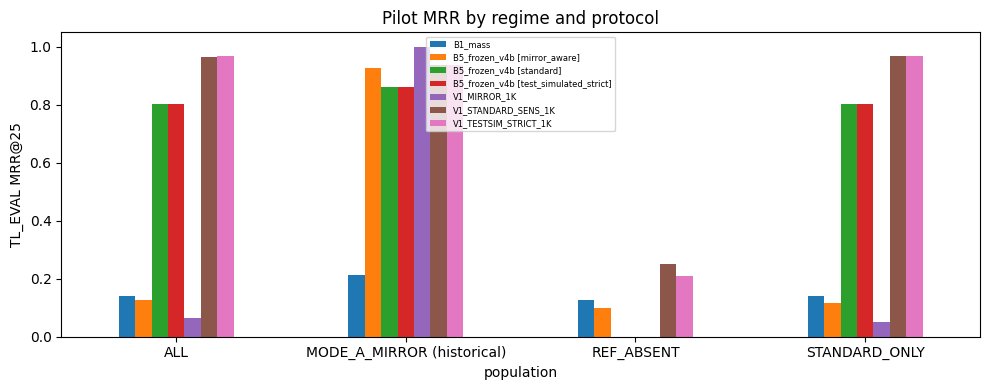

             protocol  n_train  TL_ALL  TL_MODE_A  HOST_CONFIRM
         mirror_aware       18  0.0625     1.0000        0.7473
test_simulated_strict     1000  0.9671     0.9687        0.8367
 standard_sensitivity     1000  0.9661     0.9675        0.8371

B1 mass-only: TL_ALL 0.1418

SELECTED TEST-SIMULATED SEMANTICS: test_simulated_strict | test-simulated STRICT: exclude T1+T2, allow same-source T3/T4
                property                      benchmark_mirror_aware                       test_simulated_strict               hidden_kaggle_casmi_infer  mismatch_testsim_vs_kaggle
        source exclusion                  ref_source != query_source                                        NONE             NONE (exclude_sources = {})                       False
            T1 exclusion                                         yes                                         yes                         yes (peak hash)                       False
            T2 exclusion                          

6741

In [9]:
fig, ax = plt.subplots(figsize=(10, 4))
metrics[metrics['population'].isin(['ALL', 'STANDARD_ONLY', 'MODE_A_MIRROR (historical)', 'REF_ABSENT'])].pivot_table(
    index='population', columns='model', values='mrr_at_25').plot.bar(ax=ax)
ax.set_ylabel('TL_EVAL MRR@25'); ax.legend(fontsize=6); ax.set_title('Pilot MRR by regime and protocol'); ax.tick_params(axis='x', rotation=0)
fig.tight_layout(); fig.savefig(D['figures'] / 'v52_pilot_mrr.png', dpi=120); plt.show()

summary_rows = []
for p in PROTOCOLS:
    name = {'standard': 'standard_sensitivity'}.get(p, p)
    summary_rows.append({'protocol': name, 'n_train': N_TRAIN[p], 'TL_ALL': summarize(PQ[MODEL_ID[p]])['mrr_at_25'],
                         'TL_MODE_A': summarize(PQ[MODEL_ID[p]][PQ[MODEL_ID[p]]['query_id'].isin(set(REGIME_POPS[f'MODE_A under {p}']))])['mrr_at_25'],
                         'HOST_CONFIRM': float(host_tab.set_index('protocol').loc[p, 'mrr_at_25'])})
summary_tab = pd.DataFrame(summary_rows)
print(summary_tab.to_string(index=False, float_format=lambda v: f'{v:.4f}'))
print(f"\nB1 mass-only: TL_ALL {b1_all:.4f}")
sel = GO['selected_protocol'] or GO['candidate_protocol']
sem = protocol_semantics_table(sel if sel in PROTOCOL_DEFS else 'test_simulated_strict',
                               json.loads((D['bundle'] / 'config.json').read_text(encoding='utf-8')) if (D['bundle'] / 'config.json').exists() else None)
print('\nSELECTED TEST-SIMULATED SEMANTICS:', GO['selected_protocol'], '|', PROTOCOL_DEFS[sel].label if sel in PROTOCOL_DEFS else '-')
print(sem.to_string(index=False))
print(f"\nSCALE GO: {'YES' if GO['eligible_for_scaling'] else 'NO'}")
print(f"NEXT: {GO['next_step']}")
(PILOT / 'pilot_summary.json').write_text(json.dumps({'summary': summary_rows, 'B1_TL_ALL': b1_all, 'coverage': cov, 'train_audit': TRAIN_AUDIT,
                                                      'tier_audit': {f'{k[0]}|{k[1]}': v for k, v in AUDIT.items()}, 'scale_go': GO,
                                                      'host_confirmation': host_tab.to_dict('records')}, indent=2, default=str), encoding='utf-8')